<div align="center" style="font-size:28px; font-weight:bold;">
MFE 409: Financial Risk Management
<br>Problem Set 2
<br>Valentin Haddad
<br>due 1/20 before midnight
</div>

<br>

Students:
Lee James, Moazzami Ali, Yu Aiden, Cai Jenny, Li Zehao, Guo Lucy

## 1 Expected Shortfall

#### 1. Derive a formula for the expected shortfall if gains are normally distributed $N(\mu,\sigma^2)$.

#### Solution:

Let gains $G \sim N(\mu,\sigma^2)$

Given from lecture, we have that $VaR_c = -(\mu + z(c) * \sigma)$ where $z(c) = \Phi^{-1}(c)$

ES is given by:

$$
ES = -E[X | X \le -VaR_c]
$$

Define $Z = \frac{X - \mu}{\sigma} \sim N(0,1)$ Then $X \le \mu + \sigma * z(c)$ where $Z \le z(c)$

So we get:

$$
E[Z | Z \le z(c)] = -\frac{\phi(z(c))}{1-c}
$$

Which gives:

$$
E[X | X \le \mu + \sigma * z(c)] = \mu - \sigma \frac{\phi(z(c))}{1-c}
$$

so final formula is:

$$
\begin{aligned}
ES &= -E[X | X \le -VaR_c] \\
ES &= -(\mu - \sigma \frac{\phi(z(c))}{1-c}) \\
ES &= -\mu + \sigma \frac{\phi(z(c))}{1-c}
\end{aligned}
$$

Where $\phi(z(c)) = \frac{e^{-z(c)^2 / 2}}{\sqrt{2\pi}}$

#### 2. The expected shortfall can also be defined as the average of the VaR for all confidence level above c:

$$
ES = \frac{1}{1-c}\int_c^1 VaR_\alpha d\alpha
$$

#### Prove that this definition is equivalent to the one we have seen in class.

#### Hint: You can use integration by part and a change of variable.

#### Solution:

From lecture, we have that $VaR_\alpha = -(\mu + z(\alpha) * \sigma)$ where $z(\alpha) = \Phi^{-1}(\alpha)$

Plug this into above ES equation and solve partially to get:

$$
\begin{aligned}
ES &= \frac{1}{1-c}\int_c^1 -(\mu + z(\alpha) * \sigma) d\alpha \\
   &= \frac{1}{1-c}(\int_c^1 -\mu d\alpha + \int_c^1 -z(\alpha) \sigma d\alpha) \\
ES &= -\mu - \frac{\sigma}{1-c} \int_c^1 z(\alpha) d\alpha \\
\end{aligned}
$$

Then we will use change of variable where we let $\alpha = \Phi(z)$, $z = \Phi^{-1}(\alpha)$, and $d\alpha = \phi(z)dz$ to get:

$$
\int_c^1 z(\alpha) d\alpha = \int_{z(c)}^∞ z(\Phi(z)) \phi(z)dz = \int_{z(c)}^∞ z \phi(z)dz
$$

Then we will use integration by parts where $\int z\phi(z)dz = -\phi(z)$ so:

$$
\int_{z(c)}^∞ z \phi(z)dz = -\phi(z) \mid_{z(c)}^∞ = -\phi(∞) + \phi(z(c)) = \phi(z(c))
$$

This gives ES definition equivalent to one from lecture where $\phi(z(c)) = \frac{e^{-z(c)^2 / 2}}{\sqrt{2\pi}}$:

$$
ES = -\mu + \sigma * \frac{\phi(z(c))}{1-c}
$$

## 2 Decomposing the VaR of a portfolio

### The attached python-code contains a function called “draw_returns” with one argument N. Calling the function returns N random draws for the returns of 3 assets, A, B, and C. Please take this function as given and do not modify it (assume it is a black box ).

In [ ]:
# This function creates N draws from some three random variables
import numpy as np

def draw_returns(N):
  # coin flips
  normal_year = np.random.binomial(1, 0.9, N)

  # draw for normal years
  mu = np.array([0.05, 0.05, 0.05])
  Sigma = np.array([[0.09, 0.012, 0.021], [0.012, 0.16, 0.028], [0.021, 0.028, 0.49]])
  normal_ret = np.random.multivariate_normal(mu, Sigma, N)

  # draws for special years
  mu = np.array([-0.1, -0.1, -0.1])
  Sigma = np.array([[0.36, 0.24, 0.42], [0.24, 0.64, 0.56], [0.42, 0.56, 1.96]])
  special_ret = np.random.multivariate_normal(mu, Sigma, N)

  # combine
  ret = normal_ret
  for i in range(N):
    if normal_year[i] == 0:
      ret[i,:] = special_ret[i,:]

  return(ret)

#### 1. Assume you have a portfolio of \$3m in asset A, \$4m in asset B and \$3m in asset C. What is the VaR of your portfolio? What is the CVaR and DVaR for each of the assets? Check that the sum of CVaRs coincides with VaR. Which asset is responsible for the most risk of the portfolio?

In [ ]:
np.random.seed(1234)
N = 2000000
weights = np.array([3.0, 4.0, 3.0])
returns = draw_returns(N)

port_pnl = returns @ weights

# 1. VaR (Value at Risk) 99% confidence
var = -np.percentile(port_pnl, 1)

# 2. DVaR (Marginal VaR)
# Find days where the PnL was very close to the VaR (within 0.1%)
# We average the asset returns on just those specific days
is_close_to_var = np.abs(port_pnl - (-var)) < (var * 0.001)
dvar = -returns[is_close_to_var].mean(axis=0)

# 3. CVaR (Component VaR)
# Weight * DVaR
cvar = weights * dvar

print(f"Portfolio VaR: ${var:.4f}m")
print(f"Sum of CVaRs:  ${cvar.sum():.4f}m")
print("-" * 30)
print(f"Asset A CVaR:  ${cvar[0]:.4f}m")
print(f"Asset B CVaR:  ${cvar[1]:.4f}m")
print(f"Asset C CVaR:  ${cvar[2]:.4f}m")
print("-" * 30)
print(f"Asset A DVaR:  ${dvar[0]:.4f}m")
print(f"Asset B DVaR:  ${dvar[1]:.4f}m")
print(f"Asset C DVaR:  ${dvar[2]:.4f}m")
print("-" * 30)
print(f"Riskiest Asset: Asset {['A','B','C'][np.argmax(cvar)]}")

Portfolio VaR: $10.7849m
Sum of CVaRs:  $10.7845m
------------------------------
Asset A CVaR:  $2.0431m
Asset B CVaR:  $3.6783m
Asset C CVaR:  $5.0630m
------------------------------
Asset A DVaR:  $0.6810m
Asset B DVaR:  $0.9196m
Asset C DVaR:  $1.6877m
------------------------------
Riskiest Asset: Asset C


#### 2. When you approximate the derivatives involved in DVaR and CVaR, vary the size of the position change you use. What do you observe when you change the value? Report a graph that shows the effect of different size of the step for the derivative. Explain what is happening.

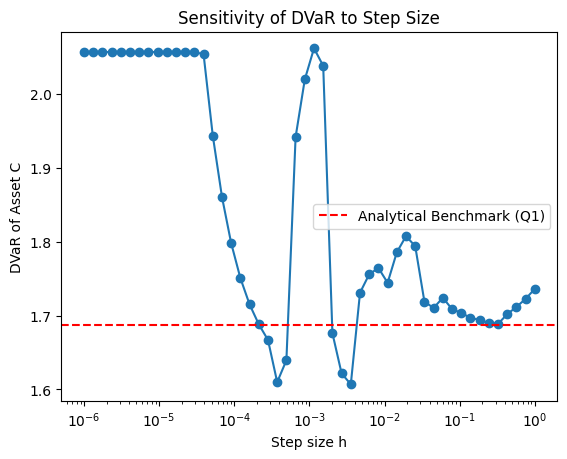

In [ ]:
import matplotlib.pyplot as plt

h_vals = np.logspace(-6, 0, 50)
dvar_C = []

for h in h_vals:
    new_weights = weights.copy()
    new_weights[2] += h

    new_pnl = returns @ new_weights
    new_var = -np.percentile(new_pnl, 1)

    dvar_val = (new_var - var) / h
    dvar_C.append(dvar_val)

plt.plot(h_vals, dvar_C, marker='o')
plt.xscale("log")
plt.xlabel("Step size h")
plt.ylabel("DVaR of Asset C")
plt.title("Sensitivity of DVaR to Step Size")
plt.axhline(y=1.6877, color='r', linestyle='--', label='Analytical Benchmark (Q1)')
plt.legend()
plt.show()

For small step sizes ($h < 10^{-4}$), the DVaR estimate plateaus at a biased value rather than the true benchmark. Because Monte Carlo VaR is determined by a single specific simulation scenario (the 1st percentile point), tiny changes in position size do not change which scenario defines the VaR. Consequently, the derivative calculation $\frac{\Delta VaR}{\Delta w}$ merely measures the return of that single outlier scenario, failing to capture the broader shape of the tail distribution.

As the step size increases ($h > 10^{-1}$), the estimate stabilizes and converges to the correct analytical benchmark (red line). A larger perturbation forces the VaR calculation to "jump" across multiple simulation scenarios, effectively averaging out the granular noise of the discrete distribution. This demonstrates that when differentiating discrete variables like VaR, a sufficiently large step size is required to smooth out local discontinuities and recover the true Marginal Risk.

#### 3. You change your portfolio to \$3m in asset A, \$5m in asset B and \$2m in asset C. What are the CVaR and DVaR for asset C?

In [ ]:
import numpy as np

weights_new = np.array([3.0, 5.0, 2.0])
port_pnl_new = returns @ weights_new

# VaR (99%)
var_new = -np.percentile(port_pnl_new, 1)

# Identify "VaR Days" (Close to the tail loss)
# We look for days where loss is within 0.1% of the VaR
epsilon = var_new * 0.001
is_close = np.abs(port_pnl_new - (-var_new)) < epsilon

# Calculate DVaR and CVaR for Asset C (Index 2)
# DVaR is the average return of Asset C on those specific bad days (flipped sign)
dvar_c_new = -returns[is_close, 2].mean()

# CVaR is Weight * DVaR
cvar_c_new = weights_new[2] * dvar_c_new

print(f"New Portfolio VaR: ${var_new:.4f}m")
print(f"Asset C CVaR:      ${cvar_c_new:.4f}m")
print(f"Asset C DVaR:      ${dvar_c_new:.4f}m")

New Portfolio VaR: $10.1433m
Asset C CVaR:      $3.2186m
Asset C DVaR:      $1.6093m


## 3 Managing a Currency Trading Desk

### Deutsche Bank (DB) is a German bank that manages its book in EUR. Consider 2 desks in DB, one is long 150 million USD and the other is short 50 million GBP. The exchange rates are 1 USD = 0.93 EUR and 1 GBP = 1.17 EUR. The daily volatilities for changes in USD/EUR and GBP/EUR are 0.40% and 0.30%, respectively and means of 1 basis point and 2 basis points. The correlation between them is 0.7. For risk calculations, assume that the returns have mean zero and are normally distributed.

#### 1. What is the 99% 1-day VaR for each desk?

#### Solution:

- USD Desk

Exposure $= 150 * 0.93 = 139.5$m EUR

$\sigma = 0.004$ and $c = 99\%$ so $z(c) = -2.326$

$VaR_{99} = -(-2.326 * 139.5 * 0.004) = 1.30$m EUR

- GBP Desk

Exposure $= 50 * 1.17 = 58.5$m EUR

$\sigma = 0.003$ and $c = 99\%$ so $z(c) = -2.326$

$VaR_{99} = -(-2.326 * 58.5 * 0.003) = 0.41$m EUR

#### 2. What is the 99% 1-day VaR for the combined portfolio?

#### Solution:

USD Position ($V_{USD}$): $€139,500,000$ and $\sigma_{USD} = 0.40\%$

GBP Position ($V_{GBP}$): $-€58,500,000$ and $\sigma_{GBP} = 0.30\%$

Correlation $\rho = 0.7$

$$
\begin{aligned}
\sigma_{Port\_Value}^2 &= (V_{USD}\sigma_{USD})^2 + (V_{GBP}\sigma_{GBP})^2 + 2(V_{USD}\sigma_{USD})(V_{GBP}\sigma_{GBP})\rho \\
\sigma_{Port\_Value}^2 &= (139.5 * 0.004)^2 + (-58.5 * 0.003)^2 + 2(139.5 * 0.004)(-58.5 * 0.003) * 0.7 \\
\sigma_{Port\_Value}^2 &= 0.311364 + 0.030800 - 0.137066 \\
\sigma_{Port\_Value}^2 &= 0.205098 \\
\sigma_{Port\_Value} &= \sqrt{0.205098} \\
\sigma_{Port\_Value} &= 0.452877
\end{aligned}
$$

so $\sigma_{Port\_Value} = 0.452877$m EUR and $c = 99\%$ so $z(c) = -2.326$

Then $VaR_{Port} = \sigma_{Port\_Value} * 2.326$

$VaR_{Port} \approx 0.452877 * 2.326 \approx 1.05$m EUR

# Optional, more challenging:

#### 3. Consider an arbitrary portfolio with positions $x_1$ and $x_2$ in two assets. If you increase your position in $x_1$ by a small amount ∆$x_1$, by how much do you need to change your position in asset 2 to keep your VaR constant? What is the effect of these changes on your expected profits? Obtain mathematical expressions as function of (some but not necessarily all of) ∆$x_1$, VaR, DVaR, CVaR, and expected returns.

N/A

#### 4. How would you change the allocation of DB's trading desk? Give a quantitative argument.

N/A